<a href="https://colab.research.google.com/github/Salsugalt/metrojam/blob/metrojam/xgboost_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from xgboost import XGBRegressor
from sklearn.base import BaseEstimator, RegressorMixin
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [3]:
from google.colab import drive
drive.mount('gdr')
data = pd.read_csv('/content/gdr/MyDrive/Dataset/line_1.csv')

Drive already mounted at gdr; to attempt to forcibly remount, call drive.mount("gdr", force_remount=True).


In [4]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (18.7 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 123633 files and direc

In [4]:
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [6]:
# 데이터를 독립변수(X)와 종속변수(y)로 나눕니다.
X = data[['time', 'day_type', 'direction', 'station_name']]
y = data['congestion']

# 범주형 열에 OneHot 인코딩을 적용
categorical_features = ['time', 'day_type', 'direction', 'station_name']
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features)],
    remainder='passthrough')  # 나머지 변수를 유지

# 데이터를 학습, 검증, 테스트 데이터로 나눕니다.
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.375, random_state=1234)

# XGBRegressor 모델 정의
xgb_reg = XGBRegressor(random_state=1234)

# 파이프라인 정의
pipeline = Pipeline([
    ('preprocessor', preprocessor),  # ColumnTransformer를 적용
    ('XGB_reg', xgb_reg)  # XGBRegressor 모델 사용
])

# 모델 학습
pipeline.fit(X_train, y_train)

# 모델을 파일로 저장합니다.
joblib.dump(pipeline, 'xgb_reg.pkl')

# 검증 데이터를 사용하여 모델의 성능을 평가합니다.
y_val_pred = pipeline.predict(X_val)

# MAE, RMSE, R2 Score 계산
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = mean_squared_error(y_val, y_val_pred, squared=False)
r2_val = r2_score(y_val, y_val_pred)

# 결과를 출력합니다.
print("Validation 성능 지표:")
print("Mean Absolute Error (MAE):", mae_val)
print("Root Mean Squared Error (RMSE):", rmse_val)
print("R-squared (R2):", r2_val)

# 테스트 데이터를 사용하여 모델의 성능을 평가합니다.
y_test_pred = pipeline.predict(X_test)

# MAE, RMSE, R2 Score 계산
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
r2_test = r2_score(y_test, y_test_pred)

# 결과를 출력합니다.
print("\nTest 성능 지표:")
print("Mean Absolute Error (MAE):", mae_test)
print("Root Mean Squared Error (RMSE):", rmse_test)
print("R-squared (R2):", r2_test)

Validation 성능 지표:
Mean Absolute Error (MAE): 4.900134457842935
Root Mean Squared Error (RMSE): 6.820926840511968
R-squared (R2): 0.7604761999894826

Test 성능 지표:
Mean Absolute Error (MAE): 4.901272419453723
Root Mean Squared Error (RMSE): 6.972557238374098
R-squared (R2): 0.7652715162879317


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [30]:
# 저장된 모델 파일을 불러옵니다.
model = joblib.load('xgb_reg.pkl')
# 예측할 데이터 예시
new_data = pd.DataFrame({'time': ['23시00분'], 'day_type': [False], 'direction': [True], 'station_name': ['서울역']})

# 예측을 수행합니다.
predicted_congestion = model.predict(new_data)

# 예측 결과를 출력합니다.
print("예측 혼잡도:", predicted_congestion)

예측 혼잡도: [12.014509]


청량리 제기동 신설동 동묘앞 동대문 종로5가 종로3가 종각 시청 서울역

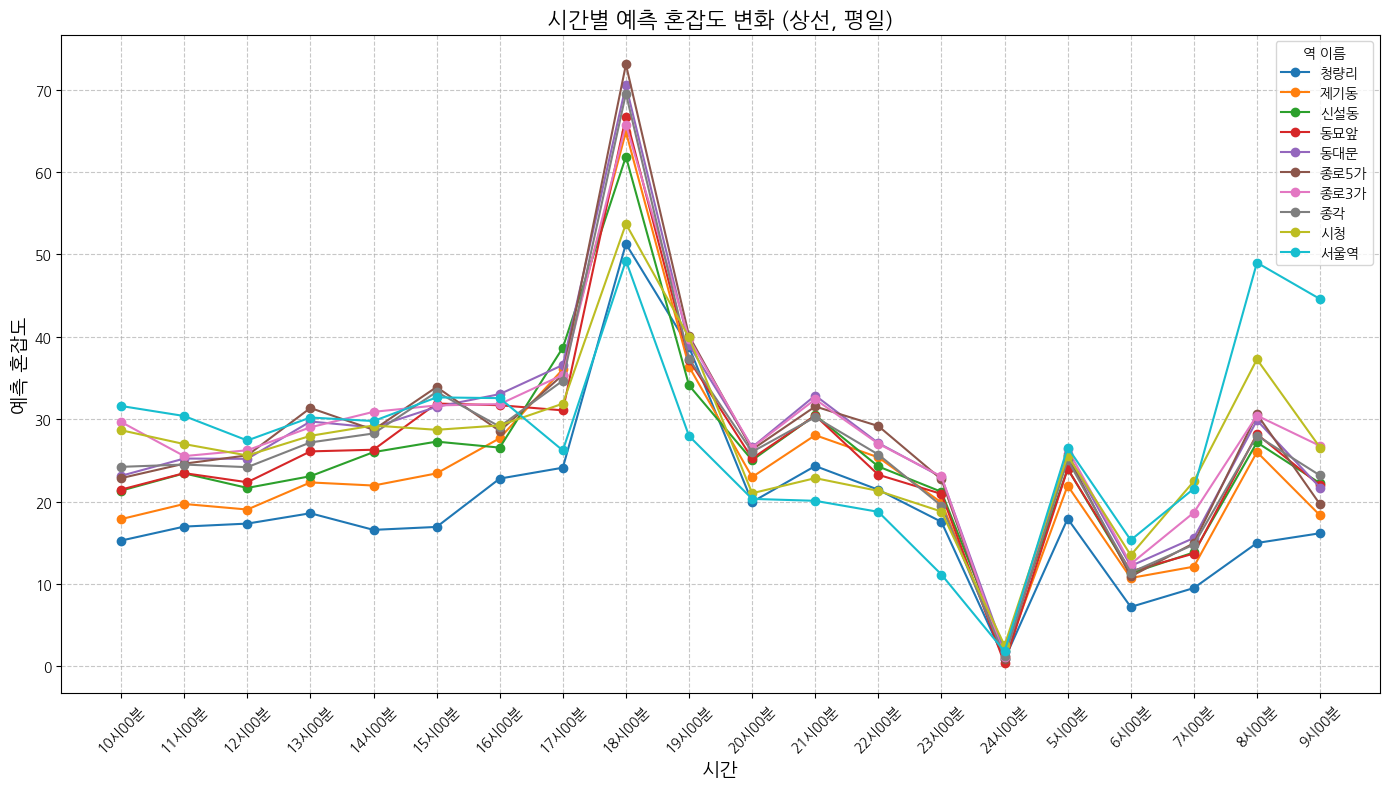

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# 모델 로드
model = joblib.load('xgb_reg.pkl')

# 역 목록과 시간 생성
stations = ['청량리', '제기동', '신설동', '동묘앞', '동대문', '종로5가', '종로3가', '종각', '시청', '서울역']
times = [f"{hour}시00분" for hour in range(5, 25)]  # 5시부터 24시까지

# 예측을 위한 데이터프레임 생성
data = []
for station in stations:
    for time in times:
        data.append({'station_name': station, 'time': time, 'direction': True, 'day_type': True})

input_data = pd.DataFrame(data)

# 모델 예측
input_data['predicted_congestion'] = model.predict(input_data)

# 시각화를 위한 데이터 정리
pivot_data = input_data.pivot(index='time', columns='station_name', values='predicted_congestion')

# 플롯 생성
plt.figure(figsize=(14, 8))

for station in stations:
    plt.plot(
        pivot_data.index,
        pivot_data[station],
        marker='o',
        label=station
    )

# 그래프 꾸미기
plt.title('시간별 예측 혼잡도 변화 (상선, 평일)', fontsize=16)
plt.xlabel('시간', fontsize=14)
plt.ylabel('예측 혼잡도', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title='역 이름', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

# 그래프 출력
plt.tight_layout()
plt.show()
